In [6]:
# !pip install selenium webdriver-manager
# !pip install undetected-chromedriver
# !pip install streamlit

In [18]:
import undetected_chromedriver as uc
from bs4 import BeautifulSoup
import pandas as pd
import time

print("جاري تشغيل المتصفح غير المكتشف (Undetected Driver)...")

# 1. إعداد المتصفح بدون بصمات آليّة
options = uc.ChromeOptions()
# options.add_argument('--headless') # اتركها معطلة حتى لا يكشفها الحظر

driver = uc.Chrome(options=options)

num_pages = 15  # عدد الصفحات التي تريد سحبها
all_job_links = []

print("\n=== بدء سحب الروابط وتخطي الحماية تلقائياً ===")

for page in range(num_pages):
    print(f"جاري فتح الصفحة رقم {page + 1}...")
    
    url = f"https://wuzzuf.net/search/jobs?q=data%20science&filters%5Bcountry%5D%5B0%5D=Egypt&start={page}"
    driver.get(url)
    
    # انتظار 5 ثواني لتخطي شاشة Cloudflare تلقائياً وتحميل الوظائف
    time.sleep(3) 
    
    soup = BeautifulSoup(driver.page_source, "html.parser")
    
    # سحب الروابط
    page_links = []
    for a_tag in soup.find_all("a", href=True):
        href = a_tag['href']
        if "/jobs/p/" in href:
            if not href.startswith("http"):
                href = "https://wuzzuf.net" + href
            page_links.append(href)
            
    page_links = list(set(page_links))
    
    if not page_links:
        print(f"⚠️ لم يتم العثور على روابط في الصفحة {page + 1}. قد تكون الوظائف انتهت.")
        break
        
    print(f"✅ تم سحب {len(page_links)} رابط نجاح من الصفحة {page + 1}")
    all_job_links.extend(page_links)

# إزالة التكرارات
all_job_links = list(set(all_job_links))
print(f"\n🔥 إجمالي الروابط الفريدة المستخرجة: {len(all_job_links)} رابط!")


# -------------------------------------------------------------
# 2. سحب تفاصيل كل وظيفة
# -------------------------------------------------------------
Job_Title, Company_Name, Location = [], [], []
Experience_Level, Years_of_Experience, Skills_And_Tools = [], [], []

if all_job_links:
    print("\n=== بدء سحب التفاصيل من داخل كل رابط ===")

    for index, link in enumerate(all_job_links, 1):
        try:
            print(f"جاري سحب الوظيفة ({index}/{len(all_job_links)})...")
            driver.get(link)
            time.sleep(1) 
            job_soup = BeautifulSoup(driver.page_source, "html.parser")
            
            # المسمى الوظيفي
            title_tag = job_soup.find("h1")
            Job_Title.append(title_tag.text.strip() if title_tag else "N/A")
                
            # اسم الشركة
            company_tag = job_soup.find("a", class_=lambda c: c and "css-" in c and "1qczh9e" in c)
            if not company_tag:
                company_tag = job_soup.find("strong")
            Company_Name.append(company_tag.text.strip() if company_tag else "N/A")
                
            # المكان
            location_tag = job_soup.find(class_=lambda c: c and "1vlp604" in c)
            if not location_tag:
                candidates = job_soup.find_all(["strong", "span"])
                for cand in candidates:
                    txt = cand.text.strip()
                    if any(place in txt for place in ["Egypt", "Cairo", "Giza", "Alexandria", "Maadi", "Dokki", "Mohandessin", "Nasr City", "Remote"]):
                        location_tag = cand
                        break
            
            if location_tag:
                loc_text = location_tag.text.strip()
                if "-" in loc_text:
                    loc_text = loc_text.split("-")[-1].strip()
                Location.append(loc_text)
            else:
                Location.append("N/A")
                
            # الخبرة وسنين الخبرة
            exp_elements = job_soup.find_all("span", class_=lambda c: c and "css-2rozun" in c)
            if len(exp_elements) >= 2:
                Years_of_Experience.append(exp_elements[0].text.strip())
                Experience_Level.append(exp_elements[1].text.strip())
            else:
                Years_of_Experience.append("N/A")
                Experience_Level.append("N/A")
                
            # المهارات منسقة
            skills_tag = job_soup.find("div", class_=lambda c: c and "css-qe7mba" in c)
            if skills_tag:
                skills_list = list(skills_tag.stripped_strings)
                skills_text = " | ".join(skills_list)
                Skills_And_Tools.append(skills_text)
            else:
                Skills_And_Tools.append("N/A")
                
        except Exception as e:
            Job_Title.append("N/A")
            Company_Name.append("N/A")
            Location.append("N/A")
            Experience_Level.append("N/A")
            Years_of_Experience.append("N/A")
            Skills_And_Tools.append("N/A")

driver.quit()

# -------------------------------------------------------------
# 3. حفظ البيانات في ملف CSV
# -------------------------------------------------------------
if all_job_links:
    wazzaf_df = pd.DataFrame({
        "Job Title": Job_Title,
        "Company Name": Company_Name,
        "Location": Location,
        "Experience Level": Experience_Level,
        "Years of Experience": Years_of_Experience,
        "Skills & Tools": Skills_And_Tools
    })

    wazzaf_df.to_csv("Wuzzuf_All_Jobs.csv", index=False, encoding="utf-8-sig")

    print("\n--- تم حفظ البيانات بنجاح في ملف Wuzzuf_All_Jobs.csv! ---")
    wazzaf_df.head()

جاري تشغيل المتصفح غير المكتشف (Undetected Driver)...

=== بدء سحب الروابط وتخطي الحماية تلقائياً ===
جاري فتح الصفحة رقم 1...
✅ تم سحب 15 رابط نجاح من الصفحة 1
جاري فتح الصفحة رقم 2...
✅ تم سحب 14 رابط نجاح من الصفحة 2
جاري فتح الصفحة رقم 3...
✅ تم سحب 14 رابط نجاح من الصفحة 3
جاري فتح الصفحة رقم 4...
✅ تم سحب 15 رابط نجاح من الصفحة 4
جاري فتح الصفحة رقم 5...
✅ تم سحب 15 رابط نجاح من الصفحة 5
جاري فتح الصفحة رقم 6...
✅ تم سحب 14 رابط نجاح من الصفحة 6
جاري فتح الصفحة رقم 7...
✅ تم سحب 15 رابط نجاح من الصفحة 7
جاري فتح الصفحة رقم 8...
✅ تم سحب 15 رابط نجاح من الصفحة 8
جاري فتح الصفحة رقم 9...
✅ تم سحب 14 رابط نجاح من الصفحة 9
جاري فتح الصفحة رقم 10...
✅ تم سحب 15 رابط نجاح من الصفحة 10
جاري فتح الصفحة رقم 11...
✅ تم سحب 14 رابط نجاح من الصفحة 11
جاري فتح الصفحة رقم 12...
✅ تم سحب 15 رابط نجاح من الصفحة 12
جاري فتح الصفحة رقم 13...
✅ تم سحب 15 رابط نجاح من الصفحة 13
جاري فتح الصفحة رقم 14...
✅ تم سحب 15 رابط نجاح من الصفحة 14
جاري فتح الصفحة رقم 15...
✅ تم سحب 8 رابط نجاح من الصفحة 15

🔥

In [2]:
import pandas as pd
import re

# 1. قراءة الملف الأصلي
df = pd.read_csv("Wuzzuf_All_Jobs.csv")


# 2. دالة بسيطة جداً لسحب الأرقام من النص
def get_experience_numbers(text):
    if pd.isna(text) or text == "N/A":
        return None, None

    # البحث عن جميع الأرقام الموجودة في الكلام
    numbers = re.findall(r"\d+", str(text))  # \d+ يعني هات الأرقام فقط

    if len(numbers) >= 2:
        return int(numbers[0]), int(numbers[1])  # لو لقيت رقمين (مثلا 3 و 5)
    elif len(numbers) == 1:
        return int(numbers[0]), int(numbers[0])  # لو رقم واحد بس (مثلا 3+)
    else:
        return None, None  # لو مفيش أرقام خالص


# 3. تطبيق الدالة وإنشاء العمودين
results = df["Years of Experience"].apply(get_experience_numbers)

df["Min_Exp"] = [r[0] for r in results]
df["Max_Exp"] = [r[1] for r in results]

# 4. حفظ الملف المظبوط
df.to_csv("Wuzzuf_Cleaned_Jobs.csv", index=False, encoding="utf-8-sig")

print("تم إصلاح المشكلة وتعبئة الأرقام بنجاح! 🎉")

تم إصلاح المشكلة وتعبئة الأرقام بنجاح! 🎉


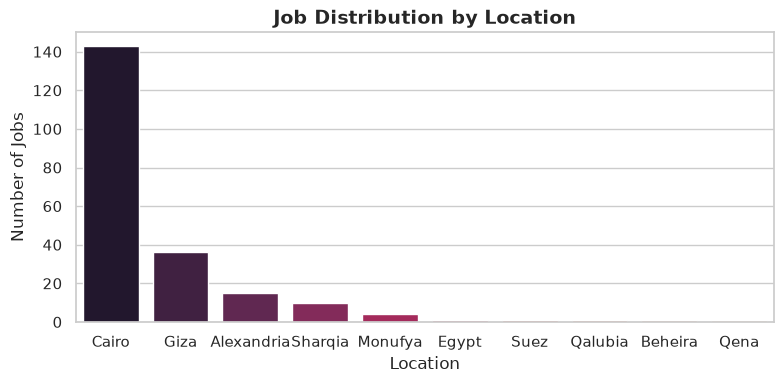

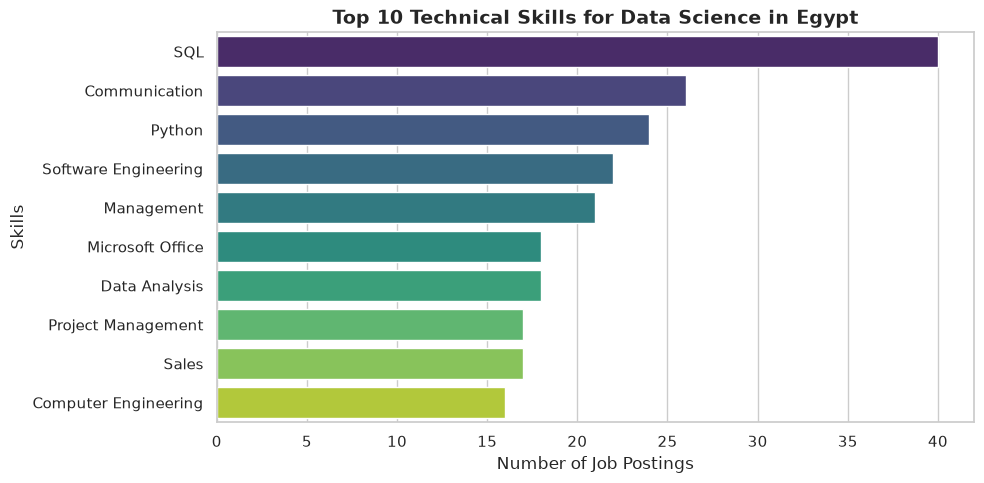

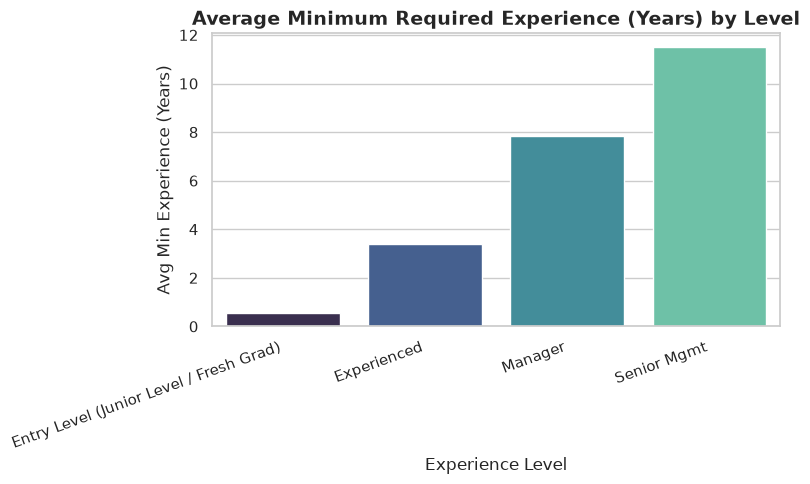

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تحميل الملف المنظف
df = pd.read_csv("Wuzzuf_Cleaned_Jobs.csv")

# ==========================================
# 🛠️ إصلاح المشكلة: إنشاء عمود المحافظات المفقود
# ==========================================
def clean_location(loc):
    if pd.isna(loc) or loc == 'N/A':
        return 'Unknown'
    loc = str(loc)
    if 'Remote' in loc:
        return 'Remote'
    elif 'Cairo' in loc:
        return 'Cairo'
    elif 'Giza' in loc:
        return 'Giza'
    elif 'Alexandria' in loc:
        return 'Alexandria'
    else:
        return loc.split(',')[-1].strip()

df['Clean_Location'] = df['Location'].apply(clean_location)
# ==========================================

# ضبط التنسيق العام للرسومات البيانية
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans' 


# -------------------------------------------------------------
# الرسمة الثانية: التوزيع الجغرافي للفرص (المحافظات)
# -------------------------------------------------------------
plt.figure(figsize=(8, 4))

location_counts = df['Clean_Location'].value_counts()

sns.barplot(x=location_counts.index, y=location_counts.values, hue=location_counts.index, palette="rocket", legend=False)
plt.title("Job Distribution by Location", fontsize=14, fontweight='bold')
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 1. إصلاح رسمة المهارات (استبعاد الكلمات العامة)
# -------------------------------------------------------------
ignore_words = [
    'Computer Science', 'Information Technology (IT)', 'Engineering', 
    'Software Development', 'Quality Assurance', 'Quality Control', 'Analysis'
]

# استبعاد الكلمات العامة
filtered_skills = exploded_skills[~exploded_skills.isin(ignore_words + ['', 'N/A'])].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=filtered_skills.values, y=filtered_skills.index, hue=filtered_skills.index, palette="viridis", legend=False)
plt.title("Top 10 Technical Skills for Data Science in Egypt", fontsize=14, fontweight='bold')
plt.xlabel("Number of Job Postings")
plt.ylabel("Skills")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 2. إصلاح رسمة الخبرة (اختصار وتدوير النصوص)
# -------------------------------------------------------------
plt.figure(figsize=(8, 5))

exp_by_level = df.groupby('Experience Level')['Min_Exp'].mean().dropna().reset_index()

# قاموس لاختصار الجمل الطويلة
short_labels = {
    'Entry Level (Junior Level Experienced Grad)': 'Entry / Junior',
    'Experienced (Non-Manager)': 'Experienced',
    'Manager': 'Manager',
    'Senior Management (CEO, GM, Director, Head)': 'Senior Mgmt'
}
exp_by_level['Short_Level'] = exp_by_level['Experience Level'].map(lambda x: short_labels.get(x, x))

sns.barplot(x='Short_Level', y='Min_Exp', data=exp_by_level, hue='Short_Level', palette="mako", legend=False)
plt.title("Average Minimum Required Experience (Years) by Level", fontsize=14, fontweight='bold')
plt.xlabel("Experience Level")
plt.ylabel("Avg Min Experience (Years)")

# تدوير الكلام بزاوية 20 درجة عشان ما يدخلش في بعضه
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

2026-09-03 11:41:21.997 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 11:41:21.998 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 11:41:22.368 
  command:

    streamlit run C:\Users\aboal\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-03 11:41:22.368 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 11:41:22.369 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 11:41:22.370 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 11:41:22.371 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

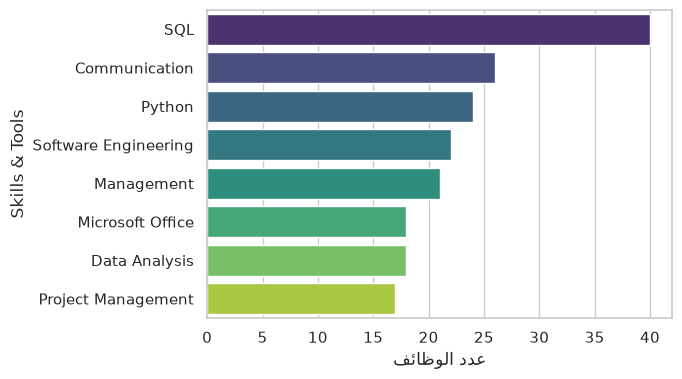

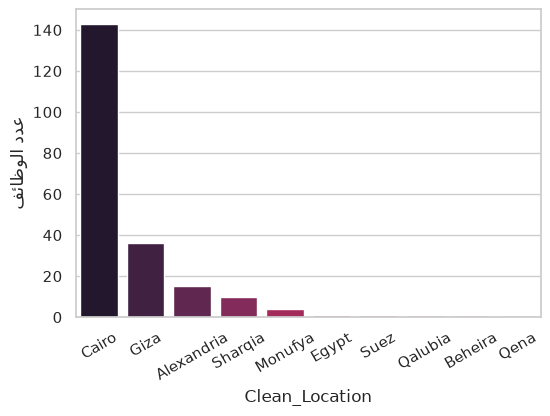

In [7]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Page configuration
st.set_page_config(page_title="Wuzzuf Data Science Jobs", layout="wide")

st.title("📊 Wuzzuf Data Science Market Dashboard (Egypt)")
st.markdown("An interactive dashboard exploring the Data Science job market in Egypt based on scraped Wuzzuf data.")

# Load and prepare data
@st.cache_data
def load_data():
    df = pd.read_csv("Wuzzuf_Cleaned_Jobs.csv")
    
    def clean_location(loc):
        if pd.isna(loc) or loc == 'N/A': return 'Unknown'
        loc = str(loc)
        if 'Remote' in loc: return 'Remote'
        elif 'Cairo' in loc: return 'Cairo'
        elif 'Giza' in loc: return 'Giza'
        elif 'Alexandria' in loc: return 'Alexandria'
        else: return loc.split(',')[-1].strip()

    df['Clean_Location'] = df['Location'].apply(clean_location)
    return df

df = load_data()

# -------------------------------------------------------------
# Sidebar Filters
# -------------------------------------------------------------
st.sidebar.header("🔍 Search Filters")

# Location Filter
locations = ["All"] + list(df['Clean_Location'].unique())
selected_loc = st.sidebar.selectbox("Select Location:", locations)

# Experience Level Filter
exp_levels = ["All"] + list(df['Experience Level'].dropna().unique())
selected_exp = st.sidebar.selectbox("Select Experience Level:", exp_levels)

# Filter dataframe
filtered_df = df.copy()
if selected_loc != "All":
    filtered_df = filtered_df[filtered_df['Clean_Location'] == selected_loc]

if selected_exp != "All":
    filtered_df = filtered_df[filtered_df['Experience Level'] == selected_exp]

# -------------------------------------------------------------
# KPI Metrics
# -------------------------------------------------------------
col1, col2, col3 = st.columns(3)
col1.metric("Total Jobs Available", len(filtered_df))
avg_min = filtered_df['Min_Exp'].mean()
col2.metric("Avg Min Experience", f"{avg_min:.1f} Yrs" if pd.notna(avg_min) else "N/A")
col3.metric("Top Location", filtered_df['Clean_Location'].mode()[0] if not filtered_df.empty else "N/A")

st.divider()

# -------------------------------------------------------------
# Visualizations
# -------------------------------------------------------------
col_chart1, col_chart2 = st.columns(2)

# Chart 1: Top Technical Skills
with col_chart1:
    st.subheader("🔥 Top Demanded Technical Skills")
    if not filtered_df.empty:
        skills_series = filtered_df['Skills & Tools'].replace('N/A', None).dropna()
        exploded_skills = skills_series.str.split(r'\s*\|\s*').explode().str.strip()
        
        ignore_words = [
            'Computer Science', 'Information Technology (IT)', 'Engineering', 
            'Software Development', 'Quality Assurance', 'Quality Control', 'Analysis'
        ]
        top_skills = exploded_skills[~exploded_skills.isin(ignore_words + ['', 'N/A'])].value_counts().head(8)

        fig1, ax1 = plt.subplots(figsize=(6, 4))
        sns.barplot(x=top_skills.values, y=top_skills.index, hue=top_skills.index, palette="viridis", legend=False, ax=ax1)
        ax1.set_xlabel("Number of Job Postings")
        st.pyplot(fig1)
    else:
        st.warning("No data available for the selected filters.")

# Chart 2: Location Distribution
with col_chart2:
    st.subheader("📍 Job Distribution by Location")
    if not filtered_df.empty:
        loc_counts = filtered_df['Clean_Location'].value_counts()
        fig2, ax2 = plt.subplots(figsize=(6, 4))
        sns.barplot(x=loc_counts.index, y=loc_counts.values, hue=loc_counts.index, palette="rocket", legend=False, ax=ax2)
        plt.xticks(rotation=30)
        ax2.set_ylabel("Number of Jobs")
        st.pyplot(fig2)

# Interactive Data Table
st.divider()
st.subheader("📋 Filtered Job Listings")
st.dataframe(filtered_df[['Job Title', 'Company Name', 'Clean_Location', 'Experience Level', 'Min_Exp', 'Skills & Tools']])